In [1]:
from PIL import Image
import numpy as np
from matplotlib.image import pil_to_array
import healpy as hp
import matplotlib.pyplot as plt

In [2]:
grayscale_pil_image = Image.open("/home/pratush/Downloads/1920px-2021-22_UN_Human_Development_Report.svg.png").convert("L") ##grayscaled the image##
image_array = pil_to_array(grayscale_pil_image) ##converted the image into an array
np.shape(image_array)

(994, 1920)

In [3]:
theta = np.linspace(0, np.pi, num=image_array.shape[0])[:,None]
phi = np.linspace(-np.pi, np.pi, num=image_array.shape[1])

In [4]:
nside = 32
print("Pixel area: %.2f square degrees" % hp.nside2pixarea(nside, degrees=True))

Pixel area: 3.36 square degrees


In [5]:
healpix_map=np.zeros(hp.nside2npix(nside))
pixel_counts=np.zeros(hp.nside2npix(nside))
for i in range(len(theta)):
    for j in range(len(phi)):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1
healpix_map/=pixel_counts

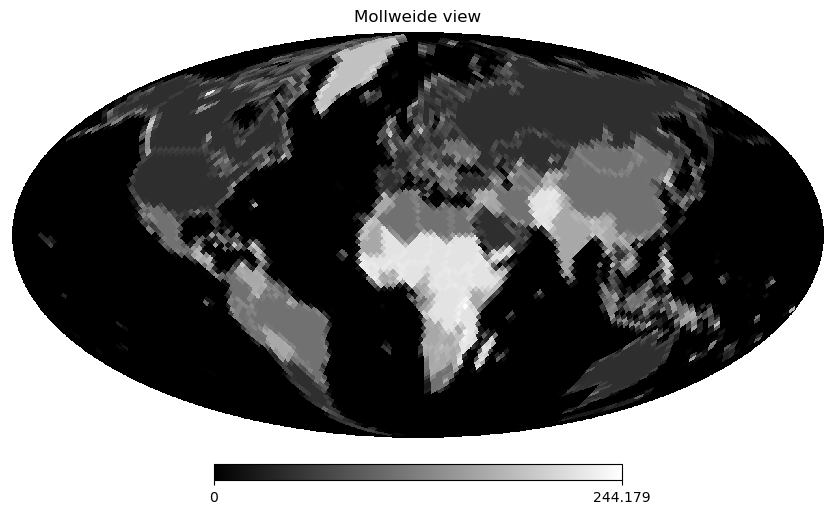

In [6]:
healpix_map[healpix_map==255]=0
hp.mollview(healpix_map, cmap="gray", xsize=2000, flip="geo")
plt.show()

In [7]:
import sys
np.set_printoptions(threshold=sys.maxsize)
print(image_array)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)

